In [326]:
from importlib import reload
reload(simulation_functions)
import numpy as np
from matplotlib import pyplot as plt

In [163]:
from scripts import simulation_functions

# Basic Bayesian learning 


In [23]:
scenes, languages = simulation_functions.define_objects()

In [27]:
# (interpretation function, word order, scene, agent x action x patient)
# contains the word that the language uses for each scene
languages.shape

(5040, 6, 36, 3)

In [28]:
5040*6

30240

Run single experiment:

In [274]:
n_trials = 30
n_participants = 5
noise_vector = np.linspace(0.2, 0.7, n_participants)

In [238]:
bayesian_results_noisefree = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=0,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=5)

In [275]:
bayesian_results_ignore = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=5)

In [276]:
bayesian_results_uniform = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector,
    return_p_scene=True,
    noise_type='uniform'
)

IntProgress(value=0, max=5)

In [350]:
bayesian_results_ignore_marginalize['history_p_scenes'].shape

(30, 20, 4)

In [354]:
def plot_bayesian_results(bayesian_results_dict, save=False):
    
    correct_fig, correct_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(5, 3), sharex=True, sharey=True
    )

    probs_fig, probs_axs = plt.subplots(
        len(bayesian_results_dict), 
        5, 
        figsize=(5, 3), sharex=True, sharey=True
    )

    for j, (noisetype, bayesian_results) in enumerate(bayesian_results_dict.items()):

        hist_p_scenes = bayesian_results['history_p_scenes']
        n_trials, n_participants, _ = hist_p_scenes.shape

        history_states = bayesian_results['history_states']
        true_interpretation_func, true_word_order = bayesian_results['indices_true_language'].T
        
        probs_true_langs = history_states[
            :,
            np.arange(n_participants),
            true_interpretation_func, 
            true_word_order
        ]

        p_correct_scene = (
            hist_p_scenes[bayesian_results['true_scenes'][:,:,None] 
            == bayesian_results['indices_scenes_trials']]
            .reshape(n_trials,-1)
        )

        axrow_correct = correct_axs[j]
        axrow_probs = probs_axs[j]

        for i, (ax_correct,ax_probs,x,y,noise) in enumerate(zip(
            axrow_correct, axrow_probs, p_correct_scene.T, probs_true_langs.T, noise_vector)):
            
            ax_correct.plot(x, color='black')
            ax_probs.plot(y, color='black')

            if i == 0:
                ax_correct.set_ylabel(noisetype)
                ax_probs.set_ylabel(noisetype)

            if j == 0:
                ax_correct.set_title(f'$\\epsilon=${noise:.2f}')
                ax_probs.set_title(f'$\\epsilon=${noise:.2f}')

    # put a title along the y axis
    correct_axs[1,0].set_title('Probability of correct scene', rotation='vertical', x=-0.8, y=0.4, va='center')
    correct_axs[-1,2].set_xlabel('Trial')
    correct_axs[0,0].set_ylim(0,1.1)


    # add space at the bottom of the figure
    correct_fig.subplots_adjust(bottom=0.15)

    probs_axs[1,0].set_title('Probability of true language', rotation='vertical', x=-0.8, y=0.4, va='center')
    probs_axs[-1,2].set_xlabel('Trial')
    probs_fig.subplots_adjust(bottom=0.15)

    if save:
        correct_fig.savefig(f'./figures/p_correct_scene.png', dpi=300)
        probs_fig.savefig(f'./figures/probs_true_lang.png', dpi=300)


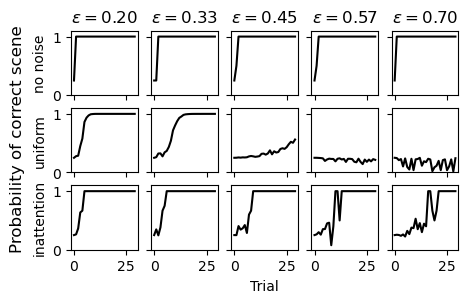

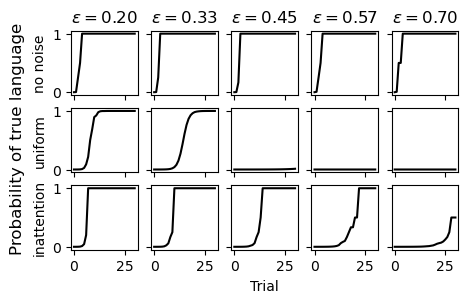

In [355]:
plot_bayesian_results({
    'no noise': bayesian_results_noisefree,
    'uniform': bayesian_results_uniform,
    'inattention': bayesian_results_ignore,
})

Plot the shape of the curves marginalized across participants

In [362]:
n_participants = 20
noise_vector = np.linspace(0.2, 0.7, n_participants)

In [363]:

bayesian_results_ignore_marginalize = simulation_functions.simulate_full_experiment(
    n_trials=n_trials, 
    n_participants=n_participants, 
    true_languages_setting='unique', 
    simulate_responses=True,
    negative_evidence=True,
    noise=noise_vector,
    return_p_scene=True,
    noise_type='ignore'
)

IntProgress(value=0, max=20)

Text(0.5, 1.0, '$\\epsilon=$0.35')

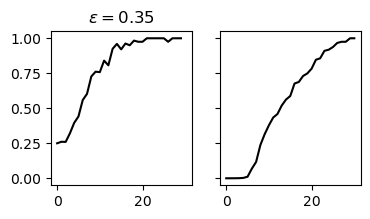

In [364]:
history_states = bayesian_results_ignore_marginalize['history_states']
true_interpretation_func, true_word_order = bayesian_results_ignore_marginalize['indices_true_language'].T
probs_true_langs_mean = history_states[
    :,
    np.arange(n_participants),
    true_interpretation_func, 
    true_word_order
].mean(axis=1)

hist_p_scenes = bayesian_results_ignore_marginalize['history_p_scenes']
p_correct_scene_mean = (
        hist_p_scenes[bayesian_results_ignore_marginalize['true_scenes'][:,:,None] 
        == bayesian_results_ignore_marginalize['indices_scenes_trials']]
        .reshape(n_trials,-1)
    ).mean(axis=1)

fig, (correct_ax, probs_ax) = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)

correct_ax.plot(p_correct_scene_mean, color='black')
probs_ax.plot(probs_true_langs_mean, color='black')

correct_ax.set_title(f'$\\epsilon=${noise:.2f}')

# Specific language

In [ ]:
index_true_language = (2,3)

scenes, languages, language_interpret, word_orders = simulation_functions.define_objects(
    full_output=True
)

word_order_prior, interpret_prior = simulation_functions.define_priors(
    word_orders, 
    language_interpret
)

trials = simulation_functions.generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

history, _ = simulation_functions.run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=True
)

In [ ]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.006944444444444444,
 0.16666666666666666,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

# Run multiple experiments:

1. Considering negative evidence (i.e., not updating when they get it wrong)

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

In [ ]:
np.array(histories).shape

(100, 11, 5040, 6)

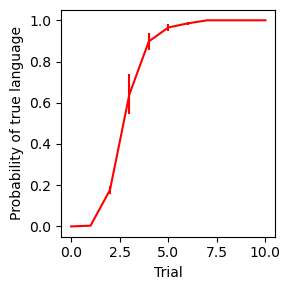

In [ ]:
fig, ax = plt.subplots(figsize=(3,3))
# ax.plot(
#     np.array(true_hists).T,
#     color='black',
#     alpha=0.05
# )
ax.errorbar(
    np.arange(len(means)), 
    means, 
    variances,
    color='red'
)
ax.set_xlabel('Trial')
ax.set_ylabel('Probability of true language')
plt.tight_layout()
fig.savefig('figures/perfectBayesian.png', dpi=300)

2. Without considering negative evidence

IntProgress(value=0)

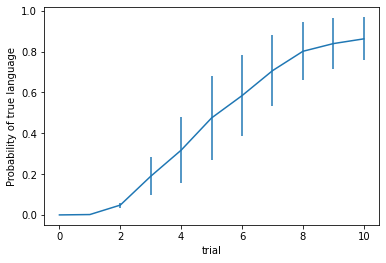

In [ ]:
index_true_language = (2,3)

histories = simulation_functions.run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()